# CASEN 2022 — comuna indicators

Merge person microdata with the geography/weights sidecar, then build comuna-level aggregates.

- **Stata read:** `convert_categoricals=False` (duplicate value labels on some columns).
- **Wide table:** `indicators` (rates are proportions 0–1).
- **Long CSV:** same shape as `cl-ine-censo` `raw_data_cl_ine_censo.csv`; `attribute_type` values match `hiap-meed` `cities_api_mock.json` metric keys (`median_household_income`, `poverty_rate`, `unemployment_rate`, `public_transport_share`). `attribute_category` is national comuna quintiles (`very low` … `very high`) for comparability with that mock vocabulary.

In [7]:
import pandas as pd

# Duplicate value labels in the file (e.g. e9rbd) break default categorical conversion.
main = pd.read_stata("./sample/casen_2022.dta", convert_categoricals=False)
geo = pd.read_stata("./sample/casen_2022_provincia_comuna.dta", convert_categoricals=False)
df = main.merge(geo, on=["folio", "id_persona"], how="inner")

In [8]:
def wshare(num, den, w):
    return (num * w).sum() / (den * w).sum()

hh = df.drop_duplicates("folio")

poverty = hh.groupby("comuna", as_index=False).apply(
    lambda g: wshare(g["pobreza"].isin([1, 2]), pd.Series(1, index=g.index), g["expc"]),
    include_groups=False,
).rename(columns={None: "poverty_rate"})

lf = df[df["activ"].isin([1, 2])]
unemp = lf.groupby("comuna", as_index=False).apply(
    lambda g: wshare(g["activ"] == 2, pd.Series(1, index=g.index), g["expc"]),
    include_groups=False,
).rename(columns={None: "unemployment_rate"})

tr = df[(df["activ"] == 1) & (df["o28c"] > 0)]
transit = tr.groupby("comuna", as_index=False).apply(
    lambda g: wshare(g["o28c"] == 1, pd.Series(1, index=g.index), g["expc"]),
    include_groups=False,
).rename(columns={None: "public_transport_commute_share"})

median_inc = hh.groupby("comuna")["ytotcorh"].median().reset_index(name="median_household_income_ytotcorh")

In [9]:
indicators = (
    median_inc.merge(poverty, on="comuna", how="outer")
    .merge(unemp, on="comuna", how="outer")
    .merge(transit, on="comuna", how="outer")
    .sort_values("comuna")
)
indicators

,comuna,median_household_income_ytotcorh,poverty_rate,unemployment_rate,public_transport_commute_share
0,1101,1174475.0,0.197225,0.090769,0.315007
1,1107,984239.0,0.344632,0.111049,0.378712
2,1401,850000.0,0.240921,0.108238,0.136259
3,1402,882500.0,0.285393,0.025316,0.000000
4,1403,537834.0,0.348802,0.118609,0.000000
...,...,...,...,...,...
330,16301,700000.0,0.326010,0.103622,0.215178
331,16302,753333.0,0.284181,0.090267,0.211253
332,16303,671448.0,0.335660,0.062676,0.040219
333,16304,738668.5,0.312741,0.032658,0.042224


In [10]:
# Long format: columns aligned with raw_data_cl_ine_censo.csv;
# attribute_type keys aligned with cities_api_mock.json city objects.

loc = pd.read_csv(
    "./sample/provincia_comuna.csv",
    usecols=["Código Región", "Nombre Región", "Código Comuna", "Nombre Comuna"],
)
loc = loc.rename(
    columns={
        "Código Región": "region",
        "Nombre Región": "region_nombre",
        "Código Comuna": "comuna",
        "Nombre Comuna": "comuna_nombre",
    }
).drop_duplicates("comuna")


def ine_short_region(name: str) -> str:
    if not isinstance(name, str):
        return name
    if name.startswith("Región Metropolitana de "):
        return "Metropolitana de Santiago"
    if name.startswith("Región de "):
        return name.removeprefix("Región de ")
    if name.startswith("Región del "):
        return name.removeprefix("Región del ")
    if name.startswith("Región "):
        return name.removeprefix("Región ")
    return name


loc["region_nombre"] = loc["region_nombre"].map(ine_short_region)

wide = indicators.merge(loc, on="comuna", how="left")
wide["median_household_income"] = wide["median_household_income_ytotcorh"]
wide["poverty_rate_pct"] = wide["poverty_rate"] * 100
wide["unemployment_rate_pct"] = wide["unemployment_rate"] * 100
wide["public_transport_share_pct"] = wide["public_transport_commute_share"] * 100

Q_LABELS = ["very low", "low", "medium", "high", "very high"]


def qcat(series):
    r = pd.to_numeric(series, errors="coerce").rank(method="first")
    try:
        return pd.qcut(r, 5, labels=Q_LABELS)
    except ValueError:
        return pd.Series("medium", index=series.index)


wide["cat_median_household_income"] = qcat(wide["median_household_income"])
wide["cat_poverty_rate"] = qcat(wide["poverty_rate_pct"])
wide["cat_unemployment_rate"] = qcat(wide["unemployment_rate_pct"])
wide["cat_public_transport_share"] = qcat(wide["public_transport_share_pct"])

parts = []
for attr_type, value_col, cat_col, units, rnd in (
    ("median_household_income", "median_household_income", "cat_median_household_income", "CLP", 0),
    ("poverty_rate", "poverty_rate_pct", "cat_poverty_rate", "percent", 2),
    ("unemployment_rate", "unemployment_rate_pct", "cat_unemployment_rate", "percent", 2),
    ("public_transport_share", "public_transport_share_pct", "cat_public_transport_share", "percent", 2),
):
    p = wide[
        [
            "region",
            "comuna",
            "region_nombre",
            "comuna_nombre",
        ]
    ].copy()
    p["attribute_type"] = attr_type
    if rnd == 0:
        p["attribute_value"] = wide[value_col].round(0)
    else:
        p["attribute_value"] = wide[value_col].round(rnd)
    p["attribute_units"] = units
    p["attribute_category"] = wide[cat_col].astype(str)
    parts.append(p)

raw_data_cl_casen_2022 = pd.concat(parts, ignore_index=True)
raw_data_cl_casen_2022.to_csv("./sample/raw_data_cl_casen_2022.csv", index=False)
raw_data_cl_casen_2022.head(8)

,region,comuna,region_nombre,comuna_nombre,attribute_type,attribute_value,attribute_units,attribute_category
0,1,1101,Tarapacá,Iquique,median_household_income,1174475.0,CLP,very high
1,1,1107,Tarapacá,Alto Hospicio,median_household_income,984239.0,CLP,high
2,1,1401,Tarapacá,Pozo Almonte,median_household_income,850000.0,CLP,medium
3,1,1402,Tarapacá,Camiña,median_household_income,882500.0,CLP,medium
4,1,1403,Tarapacá,Colchane,median_household_income,537834.0,CLP,very low
5,1,1404,Tarapacá,Huara,median_household_income,665000.0,CLP,very low
6,1,1405,Tarapacá,Pica,median_household_income,1100000.0,CLP,very high
7,2,2101,Antofagasta,Antofagasta,median_household_income,1214500.0,CLP,very high


In [11]:
raw_data_cl_casen_2022.to_csv("./data/raw_data_cl_casen_2022.csv", index=False)

## 4. Quick analysis (visual)

Comuna-level **distribution** of each wide indicator on its **own** subplot: poverty %, unemployment %, public transport commute %, and median household income (log10 CLP for readability).

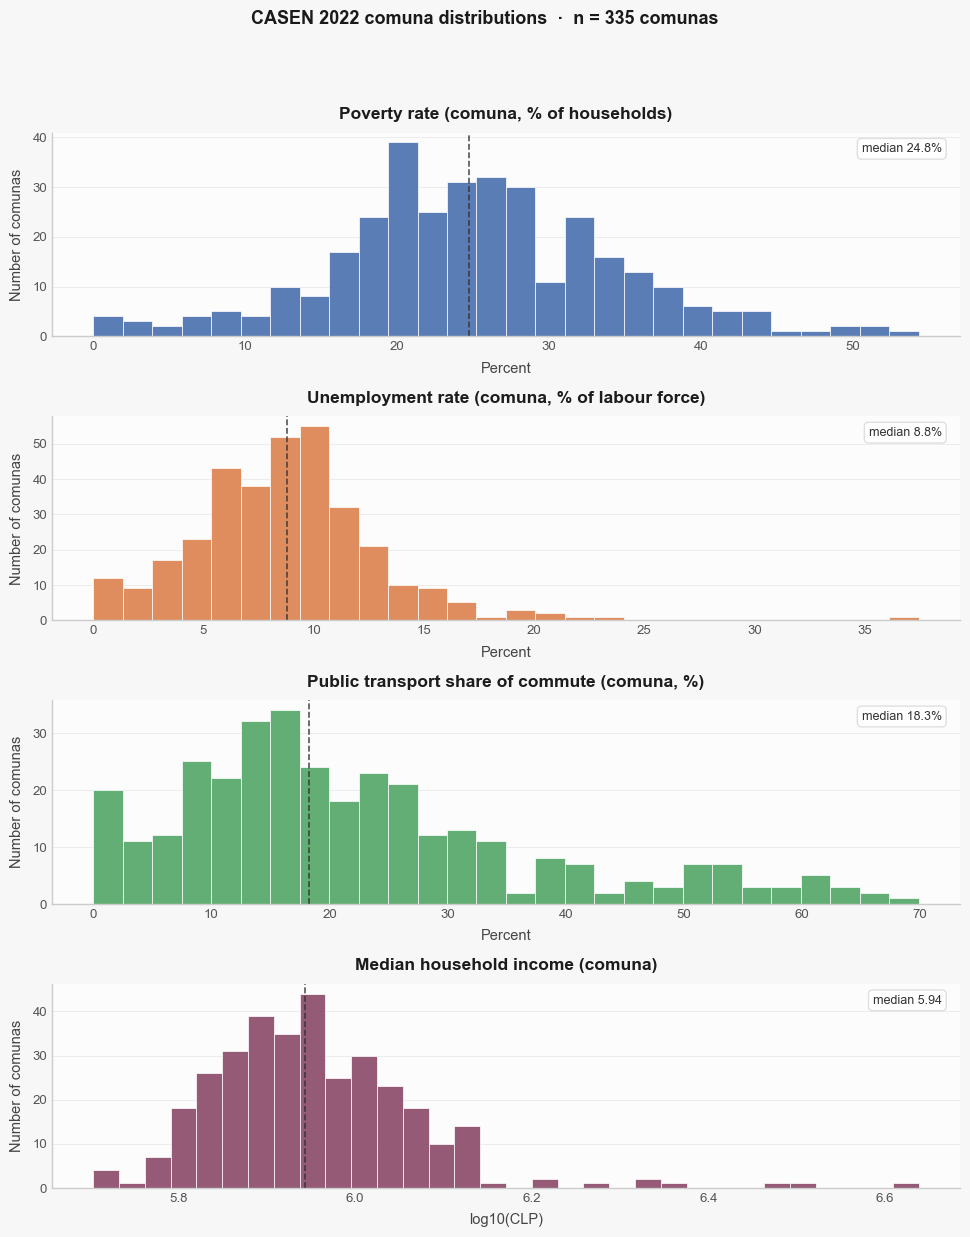

In [15]:
import matplotlib.pyplot as plt
import numpy as np

for name in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(name)
        break
    except OSError:
        continue

# Cohesive palette (colorblind-friendly, muted)
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#8B4C6B"]
FIG_BG = "#f7f7f8"
BAR_EDGE = "#ffffff"

def polish_axis(ax, title, xlabel, ylabel="Number of comunas"):
    ax.set_facecolor("#fcfcfd")
    ax.set_title(title, fontsize=12.5, fontweight="600", pad=10, color="#1c1c1c")
    ax.set_xlabel(xlabel, fontsize=10.5, color="#444444", labelpad=6)
    ax.set_ylabel(ylabel, fontsize=10.5, color="#444444", labelpad=6)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(axis="both", colors="#555555", labelsize=9.5)
    ax.grid(True, axis="y", alpha=0.38, linestyle="-", linewidth=0.6)
    ax.grid(False, axis="x")


def hist_with_median(ax, data, color, bins, xlabel, title, fmt="{:.1f}"):
    ax.hist(
        data,
        bins=bins,
        color=color,
        edgecolor=BAR_EDGE,
        linewidth=0.55,
        alpha=0.92,
    )
    med = float(np.nanmedian(data))
    ax.axvline(med, color="#2f2f2f", linestyle="--", linewidth=1.15, alpha=0.85)
    ax.text(
        0.98,
        0.95,
        f"median {fmt.format(med)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#dddddd", alpha=0.92),
    )
    polish_axis(ax, title, xlabel)


fig, axes = plt.subplots(4, 1, figsize=(9.8, 12.2), sharey=False, facecolor=FIG_BG)
fig.patch.set_facecolor(FIG_BG)

hist_with_median(
    axes[0],
    wide["poverty_rate_pct"],
    COLORS[0],
    28,
    "Percent",
    "Poverty rate (comuna, % of households)",
    fmt="{:.1f}%",
)

hist_with_median(
    axes[1],
    wide["unemployment_rate_pct"],
    COLORS[1],
    28,
    "Percent",
    "Unemployment rate (comuna, % of labour force)",
    fmt="{:.1f}%",
)

hist_with_median(
    axes[2],
    wide["public_transport_share_pct"],
    COLORS[2],
    28,
    "Percent",
    "Public transport share of commute (comuna, %)",
    fmt="{:.1f}%",
)

log_inc = np.log10(wide["median_household_income"].clip(lower=1))
hist_with_median(
    axes[3],
    log_inc,
    COLORS[3],
    32,
    "log10(CLP)",
    "Median household income (comuna)",
    fmt="{:.2f}",
)

fig.suptitle(
    f"CASEN 2022 comuna distributions  ·  n = {len(wide):,} comunas",
    fontsize=13,
    fontweight="600",
    color="#1a1a1a",
    y=1.01,
)
fig.align_ylabels(axes)
fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()
